In [19]:
import os
from pathlib import Path
import numpy as np
import torch
import h5py
import uproot
import awkward as ak
from matplotlib import pyplot as plt

In [20]:
data_root = next(
    (parent for parent in (Path.cwd(), *Path.cwd().parents) if (parent / "Data/combined_100k.root").is_file()),
    None,
)
if data_root is None:
    raise FileNotFoundError("Could not find Data/combined_100k.root in this folder or any parent folder.")
os.chdir(data_root)

file = uproot.open("Data/combined_100k.root")
file.keys()
tree = file["urqmd"]

In [21]:
tree.keys()

['mul', 'b', 'Npart', 'pid', 'px', 'py', 'pz']

In [22]:
arrays = tree.arrays(["px", "py", "pz", "mul" ,"Npart", "pid"], library="ak")

In [23]:
momentum = np.sqrt(arrays["px"]**2 + arrays["py"]**2 + arrays["pz"]**2)
safe_momentum = ak.where(momentum > 0, momentum, 1.0)
cos_theta = arrays["pz"] / safe_momentum
eps = np.finfo(np.float32).eps
cos_theta = np.minimum(np.maximum(cos_theta, -1 + eps), 1 - eps)
eta = np.arctanh(cos_theta)

In [24]:
arrays = ak.with_field(arrays, eta, "eta")

In [25]:
particle_mask = (arrays["eta"] > -1.6) & (arrays["eta"] < 1.6)
arrays_cut = ak.zip(
    {
        "px": arrays["px"][particle_mask],
        "py": arrays["py"][particle_mask],
        "pz": arrays["pz"][particle_mask],
        "pid": arrays["pid"][particle_mask],
        "eta": arrays["eta"][particle_mask],
        "mul": ak.sum(particle_mask, axis=1),
        "Npart": arrays["Npart"],
    },
    depth_limit=1,
)

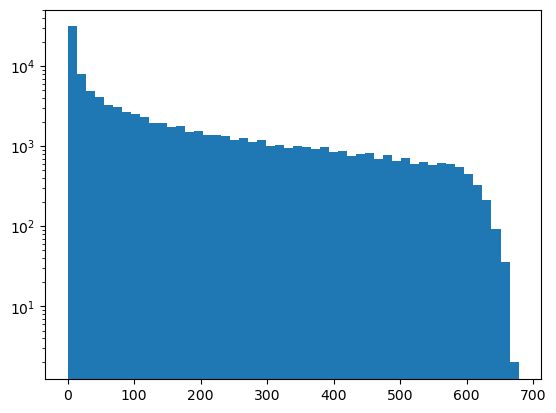

In [26]:
plt.hist(arrays_cut["mul"], bins = 50, log = True)
plt.show()

In [27]:
len(arrays_cut["mul"])

100000

In [70]:
mul = ak.to_numpy(arrays_cut["mul"])
npart = ak.to_numpy(arrays_cut["Npart"])

I want a function that gives the mean npart for a given multiplicity

I have two arrays npart and multiplicity for each 100k events. What I need is a function where I specify a multiplicity and it returns an array of the nparts with that multiplicity.


In [78]:
def npart_given_mul(npart,mul, specified_mul):
    npart_given_mul = npart[mul == specified_mul]
    return npart_given_mul
def mul_given_npart(npart,mul, specified_npart):
    mul_given_npart = mul[npart == specified_npart]
    return mul_given_npart
npart_given_mul_10 = npart_given_mul(npart, mul, 10)
npart_given_mul_10

array([11, 11, 14,  6,  9, 11, 13,  8,  7, 11, 10, 12, 19, 12, 19, 17, 11,
       10, 12,  9,  7, 12,  7,  7, 18,  8, 17, 12, 10, 14,  8, 10,  7, 11,
        9, 11,  5, 19, 15, 14, 14, 14,  7, 13, 16, 19,  8, 13,  7, 18, 20,
       16, 11, 15, 14, 13, 14, 15,  9, 12,  9, 15, 15, 13, 21,  7,  7, 10,
       18, 11, 10, 10, 11, 12, 12, 11, 10, 12, 21, 11, 12,  9,  6, 12, 13,
       11, 10, 26, 10,  9, 13, 11, 12, 12, 13,  9,  9,  7, 21,  8, 15, 13,
        8, 14, 12, 14, 16, 14,  8, 12,  9, 16, 12, 12, 18, 19, 14,  7, 13,
       10, 18,  9, 10,  7, 11,  9, 13, 12, 11, 10, 13, 17,  7, 19, 10,  9,
       18, 13, 13,  7, 22, 16, 10,  8,  6,  9,  9, 12, 14, 11, 12,  8, 14,
        5,  8, 11, 12, 15, 12,  8, 11, 10, 17, 17, 10,  9, 14, 13,  8,  7,
        6,  9,  6,  8, 11, 12,  5, 13, 13, 13, 13, 16, 14, 11, 11, 16,  9,
        7,  8, 12,  5, 10, 10,  7, 12, 11, 10, 11, 13, 12,  8, 13, 12, 14,
       14, 16, 13, 31,  9,  9, 10, 10, 14, 15,  8, 12, 19,  9, 13,  9,  7,
        5, 23,  5,  8,  7

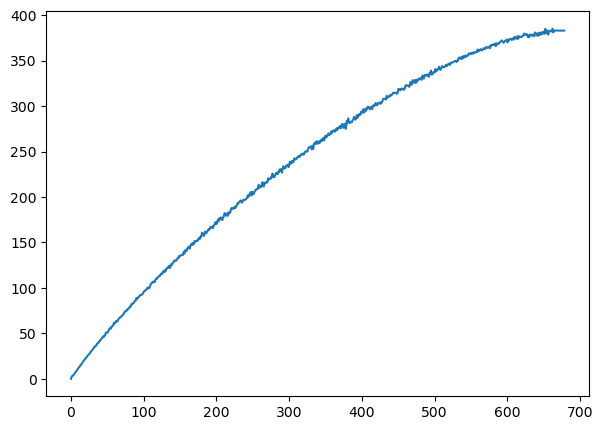

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(
    np.unique(mul),
    [np.mean(npart_given_mul(npart, mul, m)) for m in np.unique(mul)],
)


plt.show()

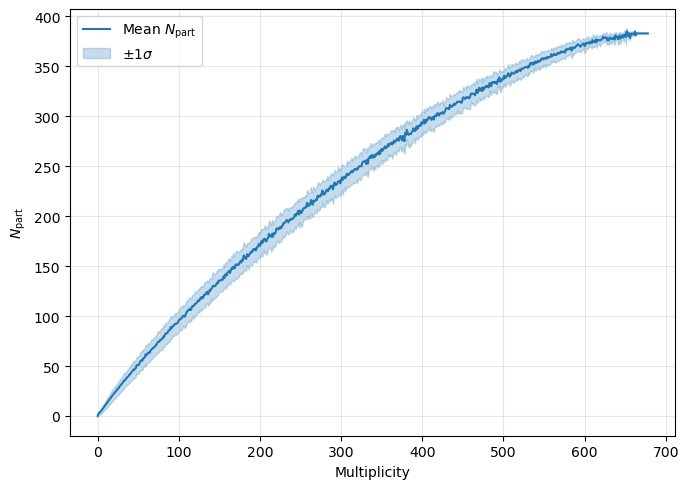

In [74]:
unique_mul = np.unique(mul)

npart_groups = [
    npart_given_mul(npart, mul, m)
    for m in unique_mul
]

mean_npart = np.array([
    np.mean(group)
    for group in npart_groups
])

std_npart = np.array([
    np.std(group)
    for group in npart_groups
])

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(
    unique_mul,
    mean_npart,
    color="tab:blue",
    label=r"Mean $N_{\mathrm{part}}$"
)

ax.fill_between(
    unique_mul,
    mean_npart - std_npart,
    mean_npart + std_npart,
    color="tab:blue",
    alpha=0.25,
    label=r"$\pm1\sigma$"
)

ax.set_xlabel("Multiplicity")
ax.set_ylabel(r"$N_{\mathrm{part}}$")
ax.legend()
ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()

In [77]:
np.max(npart)

np.int32(389)

In [81]:
sigovermean = [np.std(npart_given_mul(npart, mul, m)) / np.mean(npart_given_mul(npart, mul, m)) for m in unique_mul]

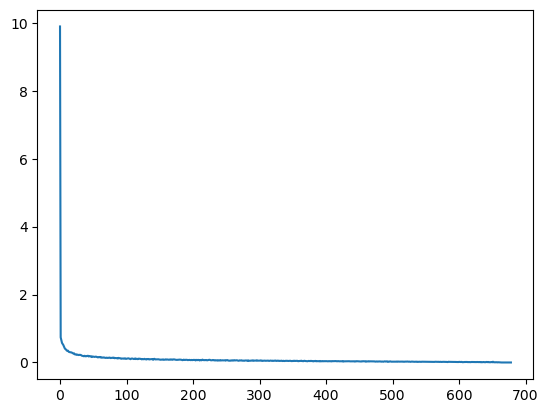

In [84]:
plt.plot(unique_mul, sigovermean)